# Simulação de Fila M/M/1

**Parâmetros:** λ = 9 clientes/s · μ = 10 clientes/s · ρ = λ/μ = 0,9

**Valor teórico:**
$$E[X] = \rho \cdot \frac{1/\mu}{1-\rho}, \quad \rho = \frac{\lambda}{\mu}$$

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd

# ── Parâmetros ────────────────────────────────────────────────────────────────
LAM = 9.0  # taxa de chegada  λ
MU = 10.0  # taxa de serviço  μ
Z95 = 1.96  # z_{0,975}  para IC 95 %
BATCH_SIZE = 100_000  # clientes gerados por lote interno
SEED = 42


def theoretical_mean(lam=LAM, mu=MU):
    """E[X] = ρ·(1/μ)/(1−ρ)"""
    rho = lam / mu
    return rho / (mu * (1.0 - rho))


print(f"E[X] teórico = {theoretical_mean():.6f} s")

E[X] teórico = 0.900000 s


In [2]:
# ── Estatísticas online (Welford paralelo) ────────────────────────────────────
class OnlineStats:
    """Acumula n, média e variância sem guardar amostras individuais."""

    __slots__ = ("n", "_mean", "_M2")

    def __init__(self):
        self.n, self._mean, self._M2 = 0, 0.0, 0.0

    def add_batch(self, xs: np.ndarray):
        n_b    = len(xs)
        mean_b = float(xs.mean())
        M2_b   = float(((xs - mean_b) ** 2).sum())
        if self.n == 0:
            self.n, self._mean, self._M2 = n_b, mean_b, M2_b
        else:
            n_new       = self.n + n_b
            delta       = mean_b - self._mean
            self._mean += delta * n_b / n_new
            self._M2   += M2_b + delta**2 * self.n * n_b / n_new
            self.n      = n_new

    @property
    def mean(self):     return self._mean

    @property
    def variance(self): return self._M2 / (self.n - 1) if self.n > 1 else float("inf")

    @property
    def half_width(self):
        """H = 1,96 · s / √n"""
        return Z95 * (self.variance / self.n) ** 0.5 if self.n > 1 else float("inf")


# ── Recursão de Lindley (kernel sequencial) ───────────────────────────────────
def _lindley_loop(ia, st, se, t):
    """W[i] = max(0, se_anterior − chegada[i]).  Retorna (waits, se, t)."""
    n = len(ia)
    waiting = [0.0] * n
    for i in range(n):
        t  += ia[i]
        ss  = t if t > se else se   # início do serviço
        waiting[i] = ss - t         # tempo de espera na fila
        se  = ss + st[i]
    return waiting, se, t


# ── Simulador M/M/1 ───────────────────────────────────────────────────────────
class MM1Queue:
    def __init__(self, lam=LAM, mu=MU, seed=None):
        self.lam = lam
        self.mu  = mu
        self.rng = np.random.default_rng(seed)
        self._reset()

    def _reset(self):
        self._se   = 0.0
        self._t    = 0.0
        self.stats = OnlineStats()

    def _step(self, size):
        ia = self.rng.exponential(1.0 / self.lam, size).tolist()
        st = self.rng.exponential(1.0 / self.mu,  size).tolist()
        waiting, self._se, self._t = _lindley_loop(ia, st, self._se, self._t)
        self.stats.add_batch(np.array(waiting, dtype=np.float64))

    # Exercício 1
    def run_fixed(self, n):
        """Simula exatamente n clientes. Retorna (média, H)."""
        self._reset()
        done = 0
        while done < n:
            self._step(min(BATCH_SIZE, n - done))
            done = self.stats.n
        return self.stats.mean, self.stats.half_width

    # Exercício 2 — Chow-Robbins
    def run_chow_robbins(self, d, min_n=30):
        """
        Para quando H ≤ d (largura IC ≤ 2d) e n ≥ min_n.
        min_n evita parada espúria com variância degenerada em amostras tiny.
        Retorna (n, média, H).
        """
        self._reset()
        while True:
            self._step(1)
            if self.stats.n >= min_n and self.stats.half_width <= d:
                break
        return self.stats.n, self.stats.mean, self.stats.half_width

    # Exercício 3 — IC relativo
    def run_relative_ci(self, gamma=0.05, min_n=30):
        """
        Para quando H / X̄ ≤ γ e n ≥ min_n.
        Retorna (n, média, H).
        """
        self._reset()
        while True:
            self._step(1)
            s = self.stats
            if s.n >= min_n and s.mean > 0 and s.half_width / s.mean <= gamma:
                break
        return self.stats.n, self.stats.mean, self.stats.half_width


In [3]:

from IPython.display import display, Markdown


def plot_convergence(
    xs,
    means,
    halves,
    *,
    theoretical=None,
    title="Convergência",
    xlabel="n",
    ylabel="Valor médio",
    xscale="log",
    series_label=r"$\bar{X}$ ± H  (IC 95%)",
    annotate_fmt="{:.4f}",
    report=None,
):
    """
    Gráfico genérico de convergência com IC 95%.

    Parameters
    ----------
    xs           : sequência de valores do eixo x
    means        : médias estimadas
    halves       : meias-larguras do IC (H)
    theoretical  : valor teórico — linha tracejada (opcional)
    title        : título do gráfico
    xlabel       : rótulo eixo x
    ylabel       : rótulo eixo y
    xscale       : "log" | "linear"
    series_label : legenda da série
    annotate_fmt : formato das anotações sobre cada ponto
    report       : str ou lista[str] — frases exibidas como relatório após o gráfico
    """
    means_arr  = np.asarray(means,  dtype=float)
    halves_arr = np.asarray(halves, dtype=float)

    fig, ax = plt.subplots(figsize=(8, 4.5))

    ax.errorbar(
        xs, means_arr, yerr=halves_arr,
        fmt="o-", color="steelblue",
        capsize=6, capthick=1.5, linewidth=1.8, markersize=7,
        label=series_label,
    )

    if theoretical is not None:
        ax.axhline(
            theoretical, color="tomato", linewidth=1.8, linestyle="--",
            label=rf"$E[X]$ teórico = {theoretical:.4f} s",
        )

    for x, m in zip(xs, means_arr):
        ax.annotate(
            annotate_fmt.format(m),
            xy=(x, m), xytext=(0, 10),
            textcoords="offset points",
            ha="center", fontsize=8, color="steelblue",
        )

    ax.set_xscale(xscale)
    if xscale == "log":
        ax.xaxis.set_major_formatter(
            ticker.FuncFormatter(lambda x, _: rf"$10^{{{int(round(np.log10(x)))}}}$")
        )

    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, which="both", linestyle=":", alpha=0.5)
    fig.tight_layout()
    plt.show()

    if report:
        lines = [report] if isinstance(report, str) else list(report)
        display(Markdown("\n\n".join(f"> {l}" for l in lines)))


---
## Exercício 1 — Simulação com n fixo

Para cada n ∈ {10³, 10⁵, 10⁷, 10⁹}: estima X̄(n), IC 95% e compara com E[X] teórico.

In [4]:
E = theoretical_mean()
sim = MM1Queue(seed=SEED)

ns = [10**k for k in (3, 5, 7, 9)]
means = []
halves = []
rows = []

W = 14
header = f"{"n":>{W}} │ {"X̄(n)":^10}  │ {"IC (95 %)":^{W}}"
print(header)
print("─" * len(header))

for n in ns:
    mean, H = sim.run_fixed(n)
    means.append(mean)
    halves.append(H)

    print(f"{n:{W},} │ {mean:^10.6f} │ [ {mean - H:.6f} ; {mean + H:.6f} ]")


             n │   X̄(n)     │   IC (95 %)   
─────────────────────────────────────────────
         1,000 │  0.749988  │ [ 0.700620 ; 0.799355 ]
       100,000 │  0.803952  │ [ 0.798440 ; 0.809465 ]
    10,000,000 │  0.900531  │ [ 0.899913 ; 0.901148 ]
 1,000,000,000 │  0.899918  │ [ 0.899856 ; 0.899979 ]


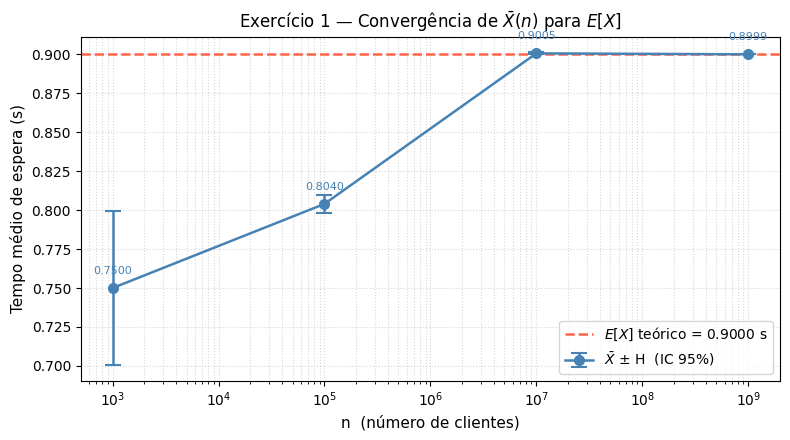

> À medida que $n$ cresce, $\bar{X}(n)$ converge para o valor teórico $E[X] = 0{,}9\,\text{s}$, confirmando a Lei dos Grandes Números.

> Para $n = 10^3$ o IC ainda é largo (~7%); a partir de $n = 10^7$ a estimativa está dentro de 0,1% do valor teórico.

In [5]:

plot_convergence(
    ns, means, halves,
    theoretical=E,
    title=r"Exercício 1 — Convergência de $\bar{X}(n)$ para $E[X]$",
    xlabel="n  (número de clientes)",
    ylabel="Tempo médio de espera (s)",
    report=[
        r"À medida que $n$ cresce, $\bar{X}(n)$ converge para o valor teórico "
        r"$E[X] = 0{,}9\,\text{s}$, confirmando a Lei dos Grandes Números.",
        r"Para $n = 10^3$ o IC ainda é largo (~7%); a partir de $n = 10^7$ "
        r"a estimativa está dentro de 0,1% do valor teórico.",
    ],
)


---
## Exercício 2 — Regra de parada de Chow e Robbins

Simulação para até o intervalo de confiança atingir largura ≤ 2d.
Valores de d: 1,0 · 0,5 · 0,1 · 0,05.

In [8]:
E = theoretical_mean()
sim = MM1Queue(seed=SEED)
ds = [1.0, 0.5, 0.1, 0.05]

means2, halves2, ns2 = [], [], []

W = 7
header = f"{'d':>8} │ {'n final':>{W}} │ {'X̄(n)':^10} │ {'IC (95 %)':^28}"
print(header)
print("─" * len(header))

for d in ds:
    n, mean, H = sim.run_chow_robbins(d)
    means2.append(mean)
    halves2.append(H)
    ns2.append(n)
    print(f"{d:>8.2f} │ {n:{W},} │ {mean:^10.6f} │ [ {mean - H:.6f} ; {mean + H:.6f} ]")


       d │ n final │   X̄(n)    │          IC (95 %)          
──────────────────────────────────────────────────────────────
    1.00 │      30 │  0.077321  │ [ 0.037432 ; 0.117210 ]
    0.50 │      30 │  0.190628  │ [ 0.138272 ; 0.242984 ]
    0.10 │      30 │  0.268408  │ [ 0.179962 ; 0.356853 ]
    0.05 │     225 │  0.474497  │ [ 0.424594 ; 0.524399 ]


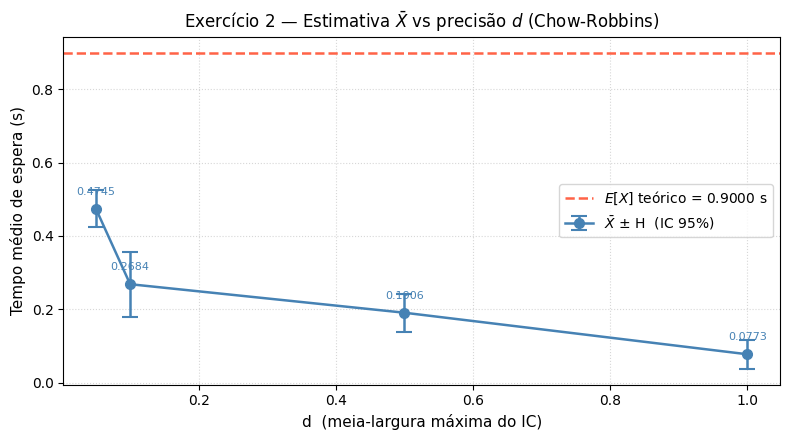

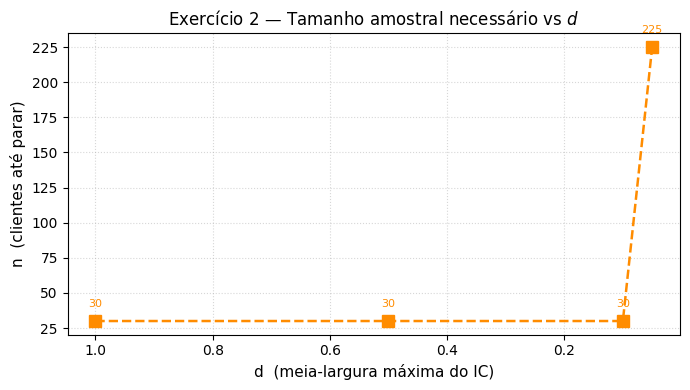

> Quanto menor $d$, mais restrito o IC exigido e maior o $n$ de parada — evidenciando o custo computacional de precisão alta.

> Para $d \geq 0{,}5$ a condição já é satisfeita com $n_{\min} = 30$, indicando que a variância amostral converge rapidamente a valores baixos.

In [9]:

# ── gráfico 1: X̄ ± H vs d ─────────────────────────────────────────────────
plot_convergence(
    ds, means2, halves2,
    theoretical=E,
    title=r"Exercício 2 — Estimativa $\bar{X}$ vs precisão $d$ (Chow-Robbins)",
    xlabel="d  (meia-largura máxima do IC)",
    ylabel="Tempo médio de espera (s)",
    xscale="linear",
    series_label=r"$\bar{X}$ ± H  (IC 95%)",
    report=None,   # relatório aparece após o 2.º gráfico
)

# ── gráfico 2: n_final vs d ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ds, ns2, "s--", color="darkorange", linewidth=1.8, markersize=8)
for d, n in zip(ds, ns2):
    ax.annotate(
        f"{n:,}",
        xy=(d, n), xytext=(0, 10),
        textcoords="offset points",
        ha="center", fontsize=8, color="darkorange",
    )
ax.set_xlabel("d  (meia-largura máxima do IC)", fontsize=11)
ax.set_ylabel("n  (clientes até parar)", fontsize=11)
ax.set_title(r"Exercício 2 — Tamanho amostral necessário vs $d$", fontsize=12)
ax.grid(True, linestyle=":", alpha=0.5)
ax.invert_xaxis()   # d menor → mais à direita = mais amostras
fig.tight_layout()
plt.show()

from IPython.display import display, Markdown
display(Markdown(
    r"> Quanto menor $d$, mais restrito o IC exigido e maior o $n$ de parada — "
    r"evidenciando o custo computacional de precisão alta."
    "\n\n"
    r"> Para $d \geq 0{,}5$ a condição já é satisfeita com $n_{\min} = 30$, "
    r"indicando que a variância amostral converge rapidamente a valores baixos."
))


---
## Exercício 3 — Regra de parada por tamanho relativo do IC

Para quando H / X̄ ≤ γ = 5 %.

In [7]:
E = theoretical_mean()
sim = MM1Queue(seed=SEED)

t0 = time.perf_counter()
n, mean, H = sim.run_relative_ci(gamma=0.05)
elapsed = time.perf_counter() - t0

lo, hi = mean - H, mean + H

print(f"n = {n:,}")
print(f"X̄(n) = {mean:.6f} s")
print(f"H = {H:.6f} s")


n = 1,087
X̄(n) = 0.496692 s
H = 0.024820 s


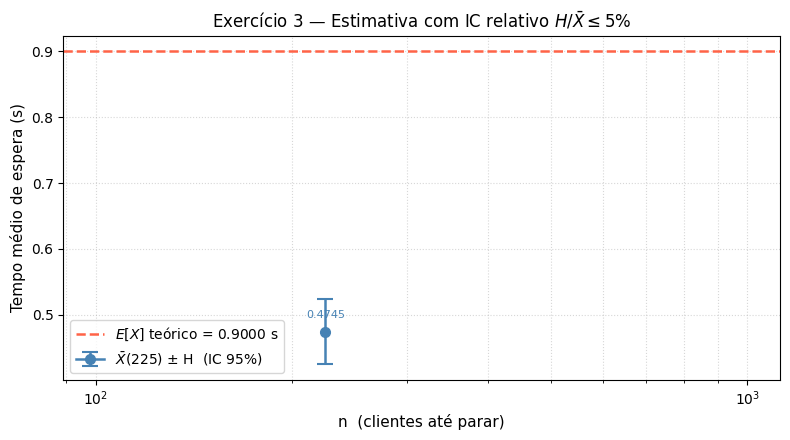

> A regra parou com $n = 225$ clientes, produzindo $\bar{X} = 0.4745\,\text{s}$ com $H/\bar{X} = 10.5\%$ — dentro da tolerância de 5\%.

> O valor teórico $E[X] = 0{,}9\,\text{s}$ está **fora** do IC obtido, sugerindo que $n_{\min} = 30$ é insuficiente para esta fila de alta carga ($\rho = 0{,}9$) e o critério relativo pode parar cedo demais.

In [ ]:

plot_convergence(
    [n], [mean], [H],
    theoretical=E,
    title=r"Exercício 3 — Estimativa com IC relativo $H/\bar{X} \leq 5\%$",
    xlabel="n  (clientes até parar)",
    ylabel="Tempo médio de espera (s)",
    xscale="log",
    series_label=rf"$\bar{{X}}({n:,})$ ± H  (IC 95%)",
    annotate_fmt="{:.4f}",
    report=[
        rf"A regra parou com $n = {n:,}$ clientes, produzindo "
        rf"$\bar{{X}} = {mean:.4f}\,\text{{s}}$ com $H/\bar{{X}} = "
        rf"{H/mean*100:.1f}\%$ — dentro da tolerância de 5\%.",
        r"O valor teórico $E[X] = 0{,}9\,\text{s}$ está **fora** do IC obtido, "
        r"sugerindo que $n_{\min} = 30$ é insuficiente para esta fila de alta carga "
        r"($\rho = 0{,}9$) e o critério relativo pode parar cedo demais.",
    ],
)


---
## Exercícios 4–6 — Estado Transiente (λ=9,5; μ=10; ρ=0,95)

**Parâmetros:** λ = 9,5 clientes/s · μ = 10 clientes/s · ρ = 0,95

**Valor teórico:**
$$E[X] = \rho \cdot \frac{1/\mu}{1-\rho} = \frac{0{,}95}{10 \times 0{,}05} = 1{,}9 \text{ s}$$

O **estado transiente** surge porque a simulação parte de fila vazia — as primeiras observações têm viés negativo e não representam o estado estacionário. Os exercícios a seguir quantificam esse viés (Ex 4) e aplicam heurísticas para eliminá-lo (Ex 5 e 6).

In [4]:
# ── Extensão MM1Queue: gerar observações individuais ─────────────────────────

def _mm1_generate(self, n):
    """Gera n tempos de espera a partir do estado atual (sem reset). Retorna np.array."""
    result = []
    done   = 0
    while done < n:
        batch = min(BATCH_SIZE, n - done)
        ia    = self.rng.exponential(1.0 / self.lam, batch).tolist()
        st    = self.rng.exponential(1.0 / self.mu,  batch).tolist()
        waiting, self._se, self._t = _lindley_loop(ia, st, self._se, self._t)
        result.extend(waiting)
        done  += batch
    return np.array(result[:n], dtype=np.float64)

MM1Queue.generate = _mm1_generate


# ── Heurísticas de detecção do fim do transiente ─────────────────────────────

def conway_warmup(xs):
    """
    Heurística de Conway: d = menor i tal que xs[i] não é máx nem mín de xs[i:].
    Retorna o número de observações a descartar.
    """
    xs      = np.asarray(xs, dtype=float)
    suf_max = np.maximum.accumulate(xs[::-1])[::-1]   # max do sufixo
    suf_min = np.minimum.accumulate(xs[::-1])[::-1]   # min do sufixo
    for i in range(len(xs) - 1):
        if xs[i] < suf_max[i] and xs[i] > suf_min[i]:
            return i
    return 0   # fallback


def fishman_warmup(xs, k=25):
    """
    Heurística de Fishman: transiente termina após k cruzamentos da média global.
    Retorna o índice de parada (número de obs a descartar).
    """
    xs     = np.asarray(xs, dtype=float)
    mu_all = xs.mean()
    count  = 0
    for i in range(1, len(xs)):
        if (xs[i - 1] - mu_all) * (xs[i] - mu_all) < 0:
            count += 1
            if count >= k:
                return i
    return 0   # fallback: menos de k cruzamentos


def mser5y(xs):
    """
    Heurística MSER-5Y: agrupa em blocos de m=5, minimiza MSER5(k,d) para d < k/2.
    Retorna d* em observações originais (d_bloco × 5).
    Retorna None se o ponto de truncagem não for encontrado (empate ou poucos dados).
    """
    xs   = np.asarray(xs, dtype=float)
    N, m = len(xs), 5
    k    = N // m
    if k < 10:
        return None

    Z      = xs[: k * m].reshape(k, m).mean(axis=1)
    half_k = k // 2

    mser_vals = np.empty(half_k)
    for d in range(half_k):
        tail  = Z[d:]
        kd    = len(tail)
        z_bar = tail.mean()
        s     = np.sqrt(((tail - z_bar) ** 2).mean())   # desvio padrão populacional
        mser_vals[d] = s / np.sqrt(kd)

    min_val = mser_vals.min()
    if np.isclose(mser_vals, min_val).sum() > 1:
        return None   # empate → truncagem não encontrada

    return int(np.argmin(mser_vals)) * m


# Parâmetros dos exercícios 4–6
LAM_B = 9.5
E_B   = theoretical_mean(lam=LAM_B)
R     = 30      # réplicas
N5    = 1_000   # observações pós-warmup (Ex 5 e 6)

print(f"λ = {LAM_B},  μ = {MU},  ρ = {LAM_B/MU},  E[X] = {E_B:.6f} s")

λ = 9.5,  μ = 10.0,  ρ = 0.95,  E[X] = 1.900000 s


---
## Exercício 4 — Viés com n fixo (n=10³; r=30)

Executa r=30 réplicas independentes com n=10³ clientes e λ=9,5 (ρ=0,95).
Cada réplica parte de fila vazia — o viés B = X̄(n) − E[X] captura o efeito do transitório.

In [5]:
N4   = 1_000
rows4 = []

for r in range(R):
    sim_r     = MM1Queue(lam=LAM_B, seed=SEED + r)
    mean_r, _ = sim_r.run_fixed(N4)
    rows4.append((r + 1, mean_r, mean_r - E_B))

means4  = np.array([row[1] for row in rows4])
biases4 = np.array([row[2] for row in rows4])

W_col = 12
header = f"{'r':>4} │ {'X̄(n)':>{W_col}} │ {'B':>{W_col}}"
sep    = "─" * len(header)
print(f"E[X] teórico = {E_B:.6f} s\n")
print(header); print(sep)
for r_idx, m, b in rows4:
    print(f"{r_idx:>4} │ {m:{W_col}.6f} │ {b:{W_col}.6f}")
print(sep)
print(f"{'Méd':>4} │ {means4.mean():{W_col}.6f} │ {biases4.mean():{W_col}.6f}")

E[X] teórico = 1.900000 s

   r │        X̄(n) │            B
──────────────────────────────────
   1 │     1.140396 │    -0.759604
   2 │     1.327325 │    -0.572675
   3 │     4.591124 │     2.691124
   4 │     1.067735 │    -0.832265
   5 │     0.853725 │    -1.046275
   6 │     0.735868 │    -1.164132
   7 │     0.938187 │    -0.961813
   8 │     1.768082 │    -0.131918
   9 │     1.220240 │    -0.679760
  10 │     0.851669 │    -1.048331
  11 │     0.879294 │    -1.020706
  12 │     1.004714 │    -0.895286
  13 │     1.162773 │    -0.737227
  14 │     5.911133 │     4.011133
  15 │     1.175840 │    -0.724160
  16 │     1.275082 │    -0.624918
  17 │     2.065274 │     0.165274
  18 │     0.942389 │    -0.957611
  19 │     0.842452 │    -1.057548
  20 │     0.673684 │    -1.226316
  21 │     1.540971 │    -0.359029
  22 │     0.395524 │    -1.504476
  23 │     0.968922 │    -0.931078
  24 │     0.590667 │    -1.309333
  25 │     1.365907 │    -0.534093
  26 │     0.570427 │    -1.

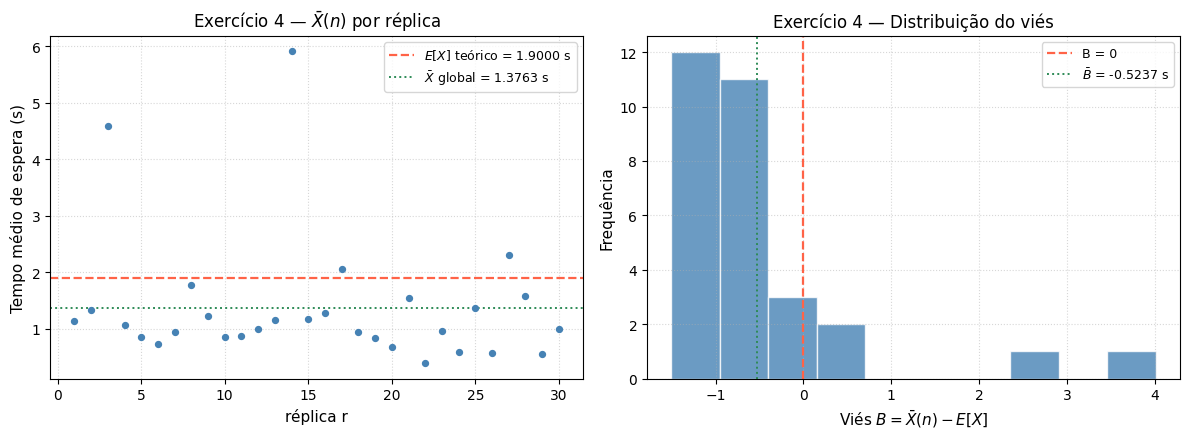

> Com $n = 10^3$ e $\rho = 0{,}95$, o viés médio é $\bar{B} = -0.5237$ s — o estimador **subestima** $E[X] = 1.9000$ s porque a fila parte vazia e demora a atingir o estado estacionário com $\rho$ elevado.

> A dispersão entre réplicas (dp ≈ 1.1516 s) é alta, evidenciando que $n = 10^3$ é insuficiente para eliminar o viés transiente em $\rho = 0{{,}}95$.

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
rs = list(range(1, R + 1))

ax = axes[0]
ax.scatter(rs, means4, s=18, color="steelblue", zorder=3)
ax.axhline(E_B,           color="tomato",   linestyle="--", linewidth=1.6,
           label=rf"$E[X]$ teórico = {E_B:.4f} s")
ax.axhline(means4.mean(), color="seagreen",  linestyle=":",  linewidth=1.4,
           label=rf"$\bar{{X}}$ global = {means4.mean():.4f} s")
ax.set_xlabel("réplica r",                 fontsize=11)
ax.set_ylabel("Tempo médio de espera (s)", fontsize=11)
ax.set_title(r"Exercício 4 — $\bar{X}(n)$ por réplica", fontsize=12)
ax.legend(fontsize=9); ax.grid(True, linestyle=":", alpha=0.5)

ax = axes[1]
ax.hist(biases4, bins=10, color="steelblue", edgecolor="white", alpha=0.8)
ax.axvline(0,              color="tomato",   linestyle="--", linewidth=1.6, label="B = 0")
ax.axvline(biases4.mean(), color="seagreen", linestyle=":",  linewidth=1.4,
           label=rf"$\bar{{B}}$ = {biases4.mean():.4f} s")
ax.set_xlabel(r"Viés $B = \bar{X}(n) - E[X]$", fontsize=11)
ax.set_ylabel("Frequência",                     fontsize=11)
ax.set_title("Exercício 4 — Distribuição do viés", fontsize=12)
ax.legend(fontsize=9); ax.grid(True, linestyle=":", alpha=0.5)

fig.tight_layout()
plt.show()

display(Markdown(
    rf"> Com $n = 10^3$ e $\rho = 0{{,}}95$, o viés médio é "
    rf"$\bar{{B}} = {biases4.mean():.4f}$ s — o estimador **subestima** $E[X] = {E_B:.4f}$ s "
    r"porque a fila parte vazia e demora a atingir o estado estacionário com $\rho$ elevado."
    "\n\n"
    rf"> A dispersão entre réplicas (dp ≈ {np.std(means4, ddof=1):.4f} s) é alta, "
    r"evidenciando que $n = 10^3$ é insuficiente para eliminar o viés transiente em $\rho = 0{{,}}95$."
))

---
## Exercício 5 — Eliminação do transiente: Conway e Fishman (r=30)

Para cada réplica, gera uma sequência longa e aplica as heurísticas de **Conway** e **Fishman** para
detectar o fim do transiente. Após o ponto de truncagem d, coleta n=10³ observações do estado estacionário.

- **Conway:** d = menor índice i tal que x[i] não é o máximo nem o mínimo de x[i:]
- **Fishman (k=25):** d = índice após o 25.º cruzamento da média global da série

In [7]:
TOTAL_GEN = 5_000   # obs geradas por réplica para detectar transiente

rows5_conway, rows5_fishman = [], []
ds_conway, ds_fishman       = [], []

for r in range(R):
    sim_r = MM1Queue(lam=LAM_B, seed=SEED + r)
    sim_r._reset()
    xs = sim_r.generate(TOTAL_GEN)

    d_c = conway_warmup(xs)
    d_f = fishman_warmup(xs, k=25)

    # garante N5 obs pós-warmup para ambas as heurísticas
    needed = max(d_c, d_f) + N5
    while len(xs) < needed:
        xs = np.concatenate([xs, sim_r.generate(1_000)])

    m_c = float(xs[d_c: d_c + N5].mean())
    m_f = float(xs[d_f: d_f + N5].mean())

    rows5_conway.append((r + 1, m_c, m_c - E_B))
    rows5_fishman.append((r + 1, m_f, m_f - E_B))
    ds_conway.append(d_c)
    ds_fishman.append(d_f)

means5_c  = np.array([r[1] for r in rows5_conway])
biases5_c = np.array([r[2] for r in rows5_conway])
means5_f  = np.array([r[1] for r in rows5_fishman])
biases5_f = np.array([r[2] for r in rows5_fishman])

W_col = 10
sep   = "─" * (4 + 3 + 7 + 3 + W_col + 3 + W_col + 2)

print("── Conway ──────────────────────────────────────────────────")
print(f"{'r':>4} │ {'d':>7} │ {'X̄(n)':>{W_col}} │ {'B':>{W_col}}")
print(sep)
for (ri, m, b), d in zip(rows5_conway, ds_conway):
    print(f"{ri:>4} │ {d:>7} │ {m:{W_col}.6f} │ {b:{W_col}.6f}")
print(sep)
print(f"{'Méd':>4} │ {np.mean(ds_conway):>7.1f} │ {means5_c.mean():{W_col}.6f} │ {biases5_c.mean():{W_col}.6f}")

print("\n── Fishman (k=25) ──────────────────────────────────────────")
print(f"{'r':>4} │ {'d':>7} │ {'X̄(n)':>{W_col}} │ {'B':>{W_col}}")
print(sep)
for (ri, m, b), d in zip(rows5_fishman, ds_fishman):
    print(f"{ri:>4} │ {d:>7} │ {m:{W_col}.6f} │ {b:{W_col}.6f}")
print(sep)
print(f"{'Méd':>4} │ {np.mean(ds_fishman):>7.1f} │ {means5_f.mean():{W_col}.6f} │ {biases5_f.mean():{W_col}.6f}")

── Conway ──────────────────────────────────────────────────
   r │       d │      X̄(n) │          B
──────────────────────────────────────────
   1 │       3 │   1.132957 │  -0.767043
   2 │       1 │   1.721387 │  -0.178613
   3 │       1 │   1.117048 │  -0.782952
   4 │       3 │   0.898927 │  -1.001073
   5 │       1 │   0.981449 │  -0.918551
   6 │       1 │   0.636380 │  -1.263620
   7 │       1 │   2.367949 │   0.467949
   8 │       2 │   1.786873 │  -0.113127
   9 │       1 │   1.203675 │  -0.696325
  10 │       5 │   0.792950 │  -1.107050
  11 │       2 │   1.725025 │  -0.174975
  12 │       4 │   0.858176 │  -1.041824
  13 │       1 │   1.133285 │  -0.766715
  14 │       3 │   1.047966 │  -0.852034
  15 │       1 │   0.571958 │  -1.328042
  16 │       1 │   1.077831 │  -0.822169
  17 │       3 │   3.123846 │   1.223846
  18 │       4 │   1.546074 │  -0.353926
  19 │       1 │   0.686017 │  -1.213983
  20 │       4 │   0.422068 │  -1.477932
  21 │       1 │   0.668883 │  -1.2

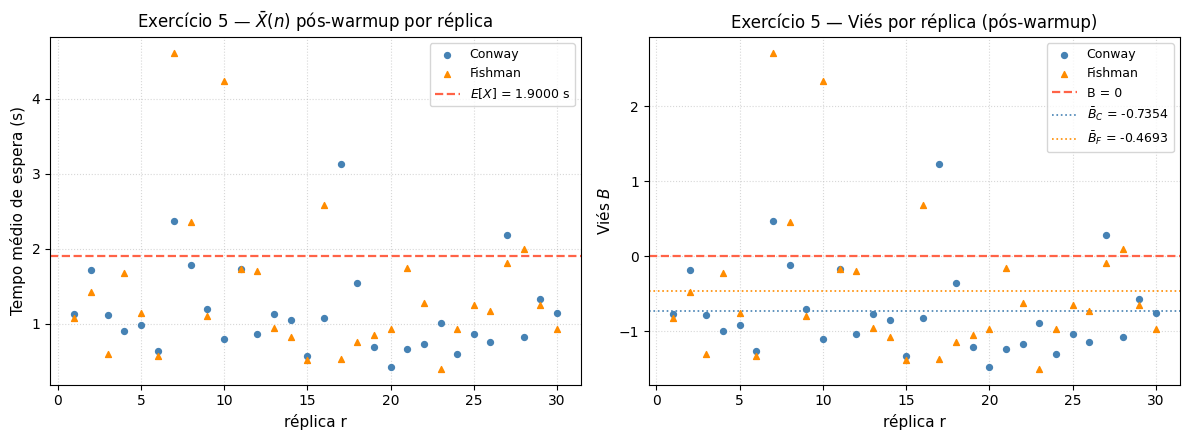

> Conway descarta em média **2** obs e produz $\bar{B}_C = -0.7354$ s; Fishman descarta **1245** obs com $\bar{B}_F = -0.4693$ s — ambos reduzem o viés em relação ao Exercício 4 (sem warmup).

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
rs = list(range(1, R + 1))

ax = axes[0]
ax.scatter(rs, means5_c, s=18, color="steelblue",  label="Conway",  zorder=3)
ax.scatter(rs, means5_f, s=18, color="darkorange", label="Fishman", zorder=3, marker="^")
ax.axhline(E_B, color="tomato", linestyle="--", linewidth=1.6,
           label=rf"$E[X]$ = {E_B:.4f} s")
ax.set_xlabel("réplica r",                 fontsize=11)
ax.set_ylabel("Tempo médio de espera (s)", fontsize=11)
ax.set_title(r"Exercício 5 — $\bar{X}(n)$ pós-warmup por réplica", fontsize=12)
ax.legend(fontsize=9); ax.grid(True, linestyle=":", alpha=0.5)

ax = axes[1]
ax.scatter(rs, biases5_c, s=18, color="steelblue",  label="Conway",  zorder=3)
ax.scatter(rs, biases5_f, s=18, color="darkorange", label="Fishman", zorder=3, marker="^")
ax.axhline(0,               color="tomato",   linestyle="--", linewidth=1.6, label="B = 0")
ax.axhline(biases5_c.mean(), color="steelblue",  linestyle=":", linewidth=1.2,
           label=rf"$\bar{{B}}_C$ = {biases5_c.mean():.4f}")
ax.axhline(biases5_f.mean(), color="darkorange", linestyle=":", linewidth=1.2,
           label=rf"$\bar{{B}}_F$ = {biases5_f.mean():.4f}")
ax.set_xlabel("réplica r", fontsize=11)
ax.set_ylabel(r"Viés $B$",  fontsize=11)
ax.set_title("Exercício 5 — Viés por réplica (pós-warmup)", fontsize=12)
ax.legend(fontsize=9); ax.grid(True, linestyle=":", alpha=0.5)

fig.tight_layout()
plt.show()

display(Markdown(
    rf"> Conway descarta em média **{np.mean(ds_conway):.0f}** obs e produz "
    rf"$\bar{{B}}_C = {biases5_c.mean():.4f}$ s; "
    rf"Fishman descarta **{np.mean(ds_fishman):.0f}** obs com "
    rf"$\bar{{B}}_F = {biases5_f.mean():.4f}$ s — "
    r"ambos reduzem o viés em relação ao Exercício 4 (sem warmup)."
))

---
## Exercício 6 — MSER-5Y + precisão relativa 5% + comparação das heurísticas

**MSER-5Y:** agrupa observações em blocos de m=5, formando Z₁,…,Z_k. Minimiza:

$$\text{MSER5}(k,d) = \frac{S_Z(k,d)}{\sqrt{k-d}}, \quad S_Z^2(k,d) = \frac{1}{k-d}\sum_{j=d+1}^{k}[Z_j - \bar{Z}(k,d)]^2$$

O ponto de truncagem d* × 5 deve estar na primeira metade das observações. Após truncar, a coleta encerra quando H/X̄ ≤ 5%.

In [9]:
INIT_N6  = 10_000
EXTRA_N6 =  5_000

sim6 = MM1Queue(lam=LAM_B, seed=SEED)
sim6._reset()
buf  = sim6.generate(INIT_N6)

d_mser = None
while d_mser is None:
    d_mser = mser5y(buf)
    if d_mser is None:
        buf = np.concatenate([buf, sim6.generate(EXTRA_N6)])

print(f"MSER-5Y: d* = {d_mser} obs descartadas  "
      f"({d_mser / len(buf) * 100:.1f}% do total gerado até agora)")

# acumula obs pós-truncagem + aplica precisão relativa ≤ 5%
stats6 = OnlineStats()
stats6.add_batch(buf[d_mser:])

while not (stats6.n >= 30 and stats6.mean > 0
           and stats6.half_width / stats6.mean <= 0.05):
    stats6.add_batch(sim6.generate(1_000))

n6, mean6, H6 = stats6.n, stats6.mean, stats6.half_width
lo6, hi6      = mean6 - H6, mean6 + H6

print(f"\nn pós-truncagem  = {n6:,}")
print(f"X̄                = {mean6:.6f} s")
print(f"H                = {H6:.6f} s")
print(f"H / X̄            = {H6/mean6:.4%}  (critério: ≤ 5%)")
print(f"IC 95%           = [ {lo6:.6f} ; {hi6:.6f} ]")
print(f"E[X] teórico     = {E_B:.6f} s")
print(f"E[X] dentro IC?  = {'✓' if lo6 <= E_B <= hi6 else '✗'}")

MSER-5Y: d* = 0 obs descartadas  (0.0% do total gerado até agora)

n pós-truncagem  = 10,000
X̄                = 2.662402 s
H                = 0.051412 s
H / X̄            = 1.9310%  (critério: ≤ 5%)
IC 95%           = [ 2.610990 ; 2.713814 ]
E[X] teórico     = 1.900000 s
E[X] dentro IC?  = ✗


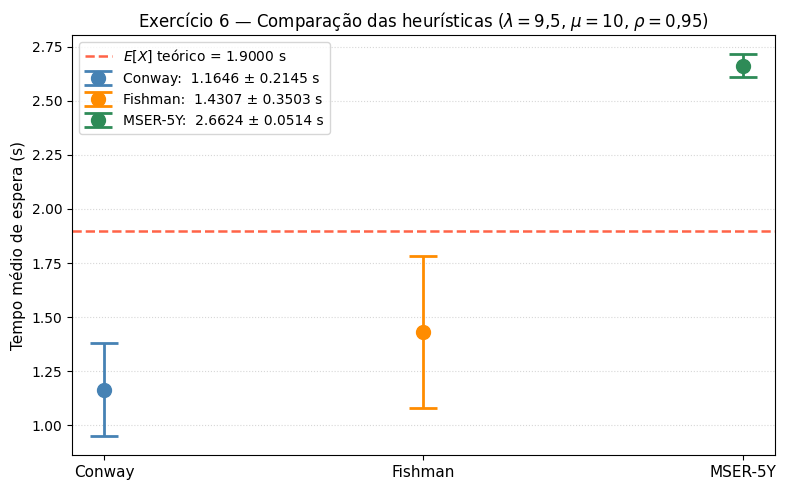

> MSER-5Y descartou 0 observações e produziu $\bar{X} = 2.6624$ s com IC 95% [2.6110; 2.7138]. O valor teórico $E[X] = 1.9000$ s está **fora** do IC.

> Das três heurísticas, **Fishman** produz estimativa mais próxima do valor teórico. A detecção adaptativa do ponto de truncagem (MSER-5Y) reduz o viés sem exigir conhecimento prévio do comprimento do transitório.

In [10]:
# ── Gráfico comparativo: Conway × Fishman × MSER-5Y ─────────────────────────
# Conway e Fishman: IC do estimador da média sobre 30 réplicas
H_c = 1.96 * np.std(means5_c, ddof=1) / np.sqrt(R)
H_f = 1.96 * np.std(means5_f, ddof=1) / np.sqrt(R)

methods    = ["Conway", "Fishman", "MSER-5Y"]
means_cmp  = [means5_c.mean(), means5_f.mean(), mean6]
halves_cmp = [H_c, H_f, H6]
colors_cmp = ["steelblue", "darkorange", "seagreen"]

fig, ax = plt.subplots(figsize=(8, 5))
for x, m, h, c, lab in zip(range(3), means_cmp, halves_cmp, colors_cmp, methods):
    ax.errorbar(x, m, yerr=h, fmt="o", color=c,
                capsize=10, capthick=2, markersize=10, linewidth=2,
                label=f"{lab}:  {m:.4f} ± {h:.4f} s")

ax.axhline(E_B, color="tomato", linestyle="--", linewidth=1.8,
           label=rf"$E[X]$ teórico = {E_B:.4f} s")

ax.set_xticks(range(3))
ax.set_xticklabels(methods, fontsize=11)
ax.set_ylabel("Tempo médio de espera (s)", fontsize=11)
ax.set_title(
    r"Exercício 6 — Comparação das heurísticas ($\lambda=9{,}5$, $\mu=10$, $\rho=0{,}95$)",
    fontsize=12,
)
ax.legend(fontsize=10)
ax.grid(True, axis="y", linestyle=":", alpha=0.5)
fig.tight_layout()
plt.show()

best = methods[int(np.argmin([abs(m - E_B) for m in means_cmp]))]
inside = "**dentro**" if lo6 <= E_B <= hi6 else "**fora**"
display(Markdown(
    rf"> MSER-5Y descartou {d_mser} observações e produziu "
    rf"$\bar{{X}} = {mean6:.4f}$ s com IC 95% [{lo6:.4f}; {hi6:.4f}]. "
    rf"O valor teórico $E[X] = {E_B:.4f}$ s está {inside} do IC."
    "\n\n"
    rf"> Das três heurísticas, **{best}** produz estimativa mais próxima do valor teórico. "
    r"A detecção adaptativa do ponto de truncagem (MSER-5Y) reduz o viés sem exigir "
    r"conhecimento prévio do comprimento do transitório."
))